# Système de recommandation agricole - Modélisation

## Librairies nécessaires

In [ ]:
# Import de base
import pandas as pd
import numpy as np
import sys,os
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath(".."))

# Import scikit learn
from sklearn.model_selection import (train_test_split, KFold, cross_validate, GridSearchCV)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

# Import des autres modèles testés
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

# Import mlflow
import mlflow
import mlflow.sklearn
mlflow.set_tracking_uri("file://" + os.path.abspath("../mlruns"))
from mlflow.tracking import MlflowClient
from mlflow.models.signature import infer_signature

# Import du projet
from scripts.preprocessing_pipeline import (
    separation_X_y,
    preparation_pipeline,
    cross_validation,
    train_predict
)

# Comparaison modèle sans optimisation sur le fichier consolidé

In [29]:
def mlflow_tracking_model(model, model_name, tags, projet_description):
    # =====================
    # Configuration MLflow
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment("Yield_Prediction_Agricultural")

    reg_name = "Yield_Forecaster_Global" 
    mlflow.sklearn.autolog(log_models=False, log_datasets=False, silent=True)

    # =======================
    # Chargement des données
    df = pd.read_csv("../data/processed/yield_df_final_conso_encoded.csv", index_col=0)
    # Lancement du run
    with mlflow.start_run(run_name=model_name, tags={
        "Training Info": tags,
        "Algorithm": model.__class__.__name__,
        "mlflow.note.content": projet_description
    }) as run:
        # Split du train_test
        X_train, X_test, y_train, y_test, categorical_cols, numeric_cols = separation_X_y(df)

        # ==========================================
        # Pipeline & Cross-Validation
        pipeline = preparation_pipeline(
            numeric_cols=numeric_cols,
            categorical_cols=categorical_cols,
            model=model
        )

        cv_results = cross_validation(pipeline=pipeline, X_train=X_train, y_train=y_train)
        
        # Calcul de la moyenne et de l'écart-type pour la CV
        cv_metrics = {
            "cv_rmse_mean": np.sqrt(-cv_results["test_mse"]).mean(),
            "cv_rmse_std": np.sqrt(-cv_results["test_mse"]).std(),
            "cv_mae_mean": (-cv_results["test_mae"]).mean(),
            "cv_mae_std": (-cv_results["test_mae"]).std(),
            "cv_r2_mean": cv_results["test_r2"].mean(),
            "cv_r2_std": cv_results["test_r2"].std()
        }
        # On log les métriques de la cv manuellement
        mlflow.log_metrics(cv_metrics)

        # Entraînement Final
        pipeline.fit(X_train, y_train)

        # ================================
        # Prédictions et métriques de test 
        y_pred = pipeline.predict(X_test)
        
       # ==========================================
        # Erreur relative moyenne (%)
        # epsilon pour éviter division par zéro
        epsilon = 1e-6
        relative_errors = np.abs((y_test - y_pred) / (np.abs(y_test) + epsilon))
        mape_pct = np.mean(relative_errors) * 100

        # Variante plus "métier" : précision relative en %
        precision_relative_pct = max(0, 100 - mape_pct)
        # taux de décisions jugées exploitables (erreur <= 10%)
        profitable_decision_rate_pct = (relative_errors <= 0.10).mean() * 100

        test_metrics = {
            "test_rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
            "test_mae": mean_absolute_error(y_test, y_pred),
            "test_mape": mean_absolute_percentage_error(y_test, y_pred),
            "test_r2": r2_score(y_test, y_pred),
            "profitability_proxy_pct": precision_relative_pct,
            "profitable_decision_rate_pct": profitable_decision_rate_pct
            }
        mlflow.log_metrics(test_metrics)

        # =================================
        # Enregistrement et Model Registry
        signature = infer_signature(X_test, y_pred)
        
        model_info = mlflow.sklearn.log_model(
            sk_model=pipeline,
            name="model",
            signature=signature,
            registered_model_name=reg_name
        )

        client = MlflowClient()
        mv = model_info.registered_model_version
        
        # Description enrichie avec la notion de stabilité (std)
        full_description = (
            f"**Modèle :** {model_name}\n"
            f"**Note :** {projet_description}\n\n"
            f"**Scores CV (Moyenne ± Écart-type) :**\n"
            f"- CV R2: {cv_metrics['cv_r2_mean']:.4f} (± {cv_metrics['cv_r2_std']:.4f})\n"
            f"- CV RMSE: {cv_metrics['cv_rmse_mean']:.2f} (± {cv_metrics['cv_rmse_std']:.2f})\n\n"
            f"**Scores Test :**\n"
            f"- Test R2: {test_metrics['test_r2']:.4f}\n"
            f"- Décisions Rentables: {profitable_decision_rate_pct:.2f}%"
        )

        client.update_model_version(name=reg_name, version=mv, description=full_description)
        
        # Tags pour comparaison rapide
        client.set_model_version_tag(reg_name, mv, "Algo", model.__class__.__name__)
        client.set_model_version_tag(reg_name, mv, "CV_R2", round(cv_metrics["cv_r2_mean"], 4))
        client.set_model_version_tag(reg_name, mv, "CV_Std", round(cv_metrics["cv_r2_std"], 4))
        client.set_model_version_tag(reg_name, mv, "Profitable_Rate", round(profitable_decision_rate_pct, 2))

        print(f"\n Version {mv} enregistrée.")
        print("\n=== Résultats métriques ===")
        print(f"CV RMSE   : {cv_metrics['cv_rmse_mean']:.4f}(± {cv_metrics['cv_rmse_std']:.2f})")
        print(f"CV MAE   : {cv_metrics['cv_mae_mean']:.4f}(±{cv_metrics['cv_mae_std']:.4f})")
        print(f"CV R2   : {cv_metrics['cv_r2_mean']:.4f}(± {cv_metrics['cv_r2_std']:.4f})")
        print(f"Test RMSE : {test_metrics['test_rmse']:.4f}")
        print(f"Test R2   : {test_metrics['test_r2']:.4f}")
        print(f"Test MAE   : {test_metrics['test_mae']:.4f}")
        print(f"Profitability_proxy_pct   : {test_metrics['profitability_proxy_pct']:.4f}")
        print(f"Profitable_decision_rate_pct   : {test_metrics['profitable_decision_rate_pct']:.4f}")

In [30]:
# DummyRegressor
model = DummyRegressor()
model_name = "DummyRegressor - Baseline"
tags = "DummyRegressor - Baseline"
projet_description = "Test d'un modèle DummyRegressor pour avoir une base sur laquelle comparer"
mlflow_tracking_model(model, model_name, tags, projet_description)

2026-04-01 10:30:04,985 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'tech_trend', 'climate_instability', 'relative_tech_intensity']
2026-04-01 10:30:04,985 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams']
/Users/florianschorer/Library/Caches/pypoetry/virtualenvs/systeme-recommandation-agricole-5e-JMIdX-py3.12/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contain


 Version 1 enregistrée.

=== Résultats métriques ===
CV RMSE   : 75652.6639(± 1271.57)
CV MAE   : 55591.4405(±612.0935)
CV R2   : -0.0007(± 0.0003)
Test RMSE : 73864.1004
Test R2   : -0.0012
Test MAE   : 54567.1261
Profitability_proxy_pct   : 0.0000
Profitable_decision_rate_pct   : 5.3164
🏃 View run DummyRegressor - Baseline at: http://127.0.0.1:5000/#/experiments/1/runs/61d319593b6c4c0f8b58208e1e62d0ba
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '1' of model 'Yield_Forecaster_Global'.


In [31]:
# Modèle de régression linéaire
model = LinearRegression()
model_name = "LinearRegression - Baseline"
tags = "LinearRegression - Baseline"
projet_description = "Test d'un modèle LinearRegression sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-01 10:30:35,020 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'tech_trend', 'climate_instability', 'relative_tech_intensity']
2026-04-01 10:30:35,020 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams']
/Users/florianschorer/Library/Caches/pypoetry/virtualenvs/systeme-recommandation-agricole-5e-JMIdX-py3.12/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contain


 Version 2 enregistrée.

=== Résultats métriques ===
CV RMSE   : 48452.9898(± 1202.51)
CV MAE   : 32395.6681(±619.6688)
CV R2   : 0.5895(± 0.0123)
Test RMSE : 48180.7848
Test R2   : 0.5740
Test MAE   : 32150.9483
Profitability_proxy_pct   : 0.0000
Profitable_decision_rate_pct   : 12.8108
🏃 View run LinearRegression - Baseline at: http://127.0.0.1:5000/#/experiments/1/runs/6df888b64e6f40dcae4f79ed13256b44
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '2' of model 'Yield_Forecaster_Global'.


In [32]:
# Modèle de RandomForest
model = RandomForestRegressor(random_state=42)
model_name = "RandomForest - Baseline"
tags = "RandomForest - Baseline"
projet_description = "Test d'un modèle Random Forest sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-01 10:31:07,916 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'tech_trend', 'climate_instability', 'relative_tech_intensity']
2026-04-01 10:31:07,917 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams']
/Users/florianschorer/Library/Caches/pypoetry/virtualenvs/systeme-recommandation-agricole-5e-JMIdX-py3.12/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contain


 Version 3 enregistrée.

=== Résultats métriques ===
CV RMSE   : 18127.0200(± 1145.55)
CV MAE   : 8505.0325(±327.6338)
CV R2   : 0.9423(± 0.0069)
Test RMSE : 17486.8506
Test R2   : 0.9439
Test MAE   : 7796.2916
Profitability_proxy_pct   : 81.3503
Profitable_decision_rate_pct   : 60.4699
🏃 View run RandomForest - Baseline at: http://127.0.0.1:5000/#/experiments/1/runs/0522616d61d5455f8c042c373e54aa14
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '3' of model 'Yield_Forecaster_Global'.


In [33]:
# Modèle de XGBoost
model = xgb.XGBRegressor(random_state=42)
model_name = "XGBRegressor - Baseline"
tags = "XGBRegressor - Baseline"
projet_description = "Test d'un modèle XGBRegressor sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-01 10:31:34,788 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'tech_trend', 'climate_instability', 'relative_tech_intensity']
2026-04-01 10:31:34,789 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams']
/Users/florianschorer/Library/Caches/pypoetry/virtualenvs/systeme-recommandation-agricole-5e-JMIdX-py3.12/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contain


 Version 4 enregistrée.

=== Résultats métriques ===
CV RMSE   : 21165.9514(± 846.73)
CV MAE   : 12710.3711(±254.1819)
CV R2   : 0.9216(± 0.0056)
Test RMSE : 20362.0486
Test R2   : 0.9239
Test MAE   : 12160.6406
Profitability_proxy_pct   : 60.0106
Profitable_decision_rate_pct   : 31.7098
🏃 View run XGBRegressor - Baseline at: http://127.0.0.1:5000/#/experiments/1/runs/41c097c3dd7f4b3aad89631b1cb323c8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '4' of model 'Yield_Forecaster_Global'.


In [34]:
# Modèle de LightGBM
model = lgb.LGBMRegressor(random_state=42, verbose=-1)
model_name = "LGBMRegressor - Baseline"
tags = "LGBMRegressor - Baseline"
projet_description = "Test d'un modèle LGBMRegressor sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-01 10:31:42,776 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'tech_trend', 'climate_instability', 'relative_tech_intensity']
2026-04-01 10:31:42,776 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams']
/Users/florianschorer/Library/Caches/pypoetry/virtualenvs/systeme-recommandation-agricole-5e-JMIdX-py3.12/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contain


 Version 5 enregistrée.

=== Résultats métriques ===
CV RMSE   : 26298.6540(± 751.19)
CV MAE   : 16708.1375(±268.1875)
CV R2   : 0.8790(± 0.0061)
Test RMSE : 26035.4246
Test R2   : 0.8756
Test MAE   : 16329.4829
Profitability_proxy_pct   : 43.6471
Profitable_decision_rate_pct   : 24.0268
🏃 View run LGBMRegressor - Baseline at: http://127.0.0.1:5000/#/experiments/1/runs/5a94cb53d6c44f4db598837013387558
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '5' of model 'Yield_Forecaster_Global'.


- Sur ces premiers tests, le modèle qui s'en sort le mieux sur l'ensemble des métriques (performance et métier) c'est celui de Random Forest.
- Les résultats de XGBoost et LightGBM sont exploitables pour essayer d'améliorer leur performance.
- Par contre le modèle de régression linéaire est trop loin en terme de performance. Au vu de la distribution de notre varibale cible, cela n'est pas étonnant.

# Comparaison modèle sans optimisation sur le fichier enrichi

In [2]:
def mlflow_tracking_model(model, model_name, tags, projet_description):
    # =====================
    # Configuration MLflow
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment("Yield_Prediction_Agricultural")

    reg_name = "Yield_Forecaster_Global" 
    mlflow.sklearn.autolog(log_models=False, log_datasets=False, silent=True)

    # =======================
    # Chargement des données
    df = pd.read_csv("../data/processed/yield_df_enriched_encoded.csv", index_col=0)
    # Lancement du run
    with mlflow.start_run(run_name=model_name, tags={
        "Training Info": tags,
        "Algorithm": model.__class__.__name__,
        "mlflow.note.content": projet_description
    }) as run:
        # Split du train_test
        X_train, X_test, y_train, y_test, categorical_cols, numeric_cols = separation_X_y(df)

        # ==========================================
        # Pipeline & Cross-Validation
        pipeline = preparation_pipeline(
            numeric_cols=numeric_cols,
            categorical_cols=categorical_cols,
            model=model
        )

        cv_results = cross_validation(pipeline=pipeline, X_train=X_train, y_train=y_train)
        
        # Calcul de la moyenne et de l'écart-type pour la CV
        cv_metrics = {
            "cv_rmse_mean": np.sqrt(-cv_results["test_mse"]).mean(),
            "cv_rmse_std": np.sqrt(-cv_results["test_mse"]).std(),
            "cv_mae_mean": (-cv_results["test_mae"]).mean(),
            "cv_mae_std": (-cv_results["test_mae"]).std(),
            "cv_r2_mean": cv_results["test_r2"].mean(),
            "cv_r2_std": cv_results["test_r2"].std()
        }
        # On log les métriques de la cv manuellement
        mlflow.log_metrics(cv_metrics)

        # Entraînement Final
        pipeline.fit(X_train, y_train)

        # ================================
        # Prédictions et métriques de test 
        y_pred = pipeline.predict(X_test)
        
       # ==========================================
        # Erreur relative moyenne (%)
        # epsilon pour éviter division par zéro
        epsilon = 1e-6
        relative_errors = np.abs((y_test - y_pred) / (np.abs(y_test) + epsilon))
        mape_pct = np.mean(relative_errors) * 100

        # Variante plus "métier" : précision relative en %
        precision_relative_pct = max(0, 100 - mape_pct)
        # taux de décisions jugées exploitables (erreur <= 10%)
        profitable_decision_rate_pct = (relative_errors <= 0.10).mean() * 100

        test_metrics = {
            "test_rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
            "test_mae": mean_absolute_error(y_test, y_pred),
            "test_mape": mean_absolute_percentage_error(y_test, y_pred),
            "test_r2": r2_score(y_test, y_pred),
            "profitability_proxy_pct": precision_relative_pct,
            "profitable_decision_rate_pct": profitable_decision_rate_pct
            }
        mlflow.log_metrics(test_metrics)

        # =================================
        # Enregistrement et Model Registry
        signature = infer_signature(X_test, y_pred)
        
        model_info = mlflow.sklearn.log_model(
            sk_model=pipeline,
            name="model",
            signature=signature,
            registered_model_name=reg_name
        )

        client = MlflowClient()
        mv = model_info.registered_model_version
        
        # Description enrichie avec la notion de stabilité (std)
        full_description = (
            f"**Modèle :** {model_name}\n"
            f"**Note :** {projet_description}\n\n"
            f"**Scores CV (Moyenne ± Écart-type) :**\n"
            f"- CV R2: {cv_metrics['cv_r2_mean']:.4f} (± {cv_metrics['cv_r2_std']:.4f})\n"
            f"- CV RMSE: {cv_metrics['cv_rmse_mean']:.2f} (± {cv_metrics['cv_rmse_std']:.2f})\n\n"
            f"**Scores Test :**\n"
            f"- Test R2: {test_metrics['test_r2']:.4f}\n"
            f"- Décisions Rentables: {profitable_decision_rate_pct:.2f}%"
        )

        client.update_model_version(name=reg_name, version=mv, description=full_description)
        
        # Tags pour comparaison rapide
        client.set_model_version_tag(reg_name, mv, "Algo", model.__class__.__name__)
        client.set_model_version_tag(reg_name, mv, "CV_R2", round(cv_metrics["cv_r2_mean"], 4))
        client.set_model_version_tag(reg_name, mv, "CV_Std", round(cv_metrics["cv_r2_std"], 4))
        client.set_model_version_tag(reg_name, mv, "Profitable_Rate", round(profitable_decision_rate_pct, 2))

        print(f"\n Version {mv} enregistrée.")
        print("\n=== Résultats métriques ===")
        print(f"CV RMSE   : {cv_metrics['cv_rmse_mean']:.4f}(± {cv_metrics['cv_rmse_std']:.2f})")
        print(f"CV MAE   : {cv_metrics['cv_mae_mean']:.4f}(±{cv_metrics['cv_mae_std']:.4f})")
        print(f"CV R2   : {cv_metrics['cv_r2_mean']:.4f}(± {cv_metrics['cv_r2_std']:.4f})")
        print(f"Test RMSE : {test_metrics['test_rmse']:.4f}")
        print(f"Test R2   : {test_metrics['test_r2']:.4f}")
        print(f"Test MAE   : {test_metrics['test_mae']:.4f}")
        print(f"Profitability_proxy_pct   : {test_metrics['profitability_proxy_pct']:.4f}")
        print(f"Profitable_decision_rate_pct   : {test_metrics['profitable_decision_rate_pct']:.4f}")

In [3]:
# DummyRegressor
model = DummyRegressor()
model_name = "DummyRegressor - Baseline - fichier enrichi"
tags = "DummyRegressor - Baseline - fichier enrichi"
projet_description = "Test d'un modèle DummyRegressor pour avoir une base sur laquelle comparer"
mlflow_tracking_model(model, model_name, tags, projet_description)

2026-04-01 15:02:26,803 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'tech_trend', 'irrigation_impact', 'climate_instability', 'relative_tech_intensity']
2026-04-01 15:02:26,803 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams', 'fertilizer_used_false', 'fertilizer_used_true', 'irrigation_used_false', 'irrigation_used_true', 'weather_condition_cloudy', 'weather_condition_rainy', 'weather_condition_sunny', 'so


 Version 6 enregistrée.

=== Résultats métriques ===
CV RMSE   : 75652.6639(± 1271.57)
CV MAE   : 55591.4405(±612.0935)
CV R2   : -0.0007(± 0.0003)
Test RMSE : 73864.1004
Test R2   : -0.0012
Test MAE   : 54567.1261
Profitability_proxy_pct   : 0.0000
Profitable_decision_rate_pct   : 5.3164
🏃 View run DummyRegressor - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/1/runs/5ed86060486b4ee997f79b930a7c3223
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '6' of model 'Yield_Forecaster_Global'.


In [4]:
# Modèle de régression linéaire
model = LinearRegression()
model_name = "LinearRegression - Baseline - fichier enrichi"
tags = "LinearRegression - Baseline - fichier enrichi"
projet_description = "Test d'un modèle LinearRegression sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-01 15:03:12,177 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'tech_trend', 'irrigation_impact', 'climate_instability', 'relative_tech_intensity']
2026-04-01 15:03:12,177 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams', 'fertilizer_used_false', 'fertilizer_used_true', 'irrigation_used_false', 'irrigation_used_true', 'weather_condition_cloudy', 'weather_condition_rainy', 'weather_condition_sunny', 'so


 Version 7 enregistrée.

=== Résultats métriques ===
CV RMSE   : 48458.7554(± 1195.87)
CV MAE   : 32385.9859(±606.1592)
CV R2   : 0.5894(± 0.0122)
Test RMSE : 48168.1604
Test R2   : 0.5742
Test MAE   : 32134.6345
Profitability_proxy_pct   : 0.0000
Profitable_decision_rate_pct   : 12.7079
🏃 View run LinearRegression - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/1/runs/cda24b5be57e4ae5bcb7edfddb5a7fe7
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '7' of model 'Yield_Forecaster_Global'.


In [5]:
# Modèle de RandomForest
model = RandomForestRegressor(random_state=42)
model_name = "RandomForest - Baseline - fichier enrichi"
tags = "RandomForest - Baseline"
projet_description = "Test d'un modèle Random Forest sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-01 15:03:40,313 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'tech_trend', 'irrigation_impact', 'climate_instability', 'relative_tech_intensity']
2026-04-01 15:03:40,313 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams', 'fertilizer_used_false', 'fertilizer_used_true', 'irrigation_used_false', 'irrigation_used_true', 'weather_condition_cloudy', 'weather_condition_rainy', 'weather_condition_sunny', 'so


 Version 8 enregistrée.

=== Résultats métriques ===
CV RMSE   : 18502.7297(± 1083.85)
CV MAE   : 9128.6996(±351.2340)
CV R2   : 0.9400(± 0.0064)
Test RMSE : 17638.6699
Test R2   : 0.9429
Test MAE   : 8281.8119
Profitability_proxy_pct   : 79.4753
Profitable_decision_rate_pct   : 56.3711
🏃 View run RandomForest - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/1/runs/ae567c3c50d24c66a0ee492fe2d9efaf
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '8' of model 'Yield_Forecaster_Global'.


In [6]:
# Modèle de XGBoost
model = xgb.XGBRegressor(random_state=42)
model_name = "XGBRegressor - Baseline - fichier enrichi"
tags = "XGBRegressor - Baseline - fichier enrichi"
projet_description = "Test d'un modèle XGBRegressor sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)

2026-04-01 15:04:52,568 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'tech_trend', 'irrigation_impact', 'climate_instability', 'relative_tech_intensity']
2026-04-01 15:04:52,568 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams', 'fertilizer_used_false', 'fertilizer_used_true', 'irrigation_used_false', 'irrigation_used_true', 'weather_condition_cloudy', 'weather_condition_rainy', 'weather_condition_sunny', 'so


 Version 9 enregistrée.

=== Résultats métriques ===
CV RMSE   : 21594.2248(± 1032.84)
CV MAE   : 13005.7313(±264.1568)
CV R2   : 0.9183(± 0.0072)
Test RMSE : 20784.7675
Test R2   : 0.9207
Test MAE   : 12253.4619
Profitability_proxy_pct   : 61.1283
Profitable_decision_rate_pct   : 32.5845
🏃 View run XGBRegressor - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/1/runs/2f147cfc177c44448e4349480e404aab
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '9' of model 'Yield_Forecaster_Global'.


In [7]:
# Modèle de LightGBM
model = lgb.LGBMRegressor(random_state=42, verbose=-1)
model_name = "LGBMRegressor - Baseline - fichier enrichi"
tags = "LGBMRegressor - Baseline - fichier enrichi"
projet_description = "Test d'un modèle LGBMRegressor sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)

2026-04-01 15:06:04,954 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'tech_trend', 'irrigation_impact', 'climate_instability', 'relative_tech_intensity']
2026-04-01 15:06:04,954 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams', 'fertilizer_used_false', 'fertilizer_used_true', 'irrigation_used_false', 'irrigation_used_true', 'weather_condition_cloudy', 'weather_condition_rainy', 'weather_condition_sunny', 'so


 Version 10 enregistrée.

=== Résultats métriques ===
CV RMSE   : 26499.9431(± 671.19)
CV MAE   : 16859.2149(±259.1014)
CV R2   : 0.8771(± 0.0057)
Test RMSE : 25907.2720
Test R2   : 0.8768
Test MAE   : 16328.3666
Profitability_proxy_pct   : 43.6776
Profitable_decision_rate_pct   : 23.9239
🏃 View run LGBMRegressor - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/1/runs/0f22f4ac9fb34edfaa11f49157096c41
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '10' of model 'Yield_Forecaster_Global'.


# Optimisation des hyperparamètres sur RandomForest / XGBoost & LightGBM

A l'aide de gridsearchCV, on va essayer ici de trouver les meilleurs hyperparamètres pour chacun des modèles

In [28]:
def mlflow_tracking_gridsearch(model, model_name, param_grid, tags, projet_description):
    # ==========================================
    # Configuration MLflow
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment("Yield_Prediction_Agricultural")
    reg_name = "Yield_Forecaster_GridSearch"
    mlflow.sklearn.autolog(log_models=False, log_datasets=False, silent=True, max_tuning_runs=0)

    df = pd.read_csv("../data/processed/yield_df_final_conso_encoded.csv", index_col=0)

    with mlflow.start_run(run_name=f"GridSearch - {model_name}") as run:
        X_train, X_test, y_train, y_test, categorical_cols, numeric_cols = separation_X_y(df)
        pipeline = preparation_pipeline(numeric_cols, categorical_cols, model)
        cv = KFold(n_splits=5, shuffle=True, random_state=42)

        mlflow.set_tag("model_family", "RandomForest")
        mlflow.set_tag("optimization_metric", "MAE")
        mlflow.set_tag("search_type", "GridSearchCV")
        mlflow.set_tag("project", "Yield_Prediction_Agricultural")
        mlflow.set_tag("dataset_version", "yield_df_final_conso_encoded")
        mlflow.set_tag("run_purpose", "hyperparameter_tuning")
        
        # On utilise GridSearchCV
        grid_search = GridSearchCV(
            estimator=pipeline, 
            param_grid=param_grid, 
            scoring='r2', 
            n_jobs=-1, 
            cv=cv,
            refit=True,
            error_score='raise'
        )
        grid_search.fit(X_train, y_train)
        
        # --- Récupération des meilleurs stats de la cv---
        best_index = grid_search.best_index_
        # Le MAE moyen et son écart-type
        cv_r2_mean = grid_search.best_score_
        cv_r2_std = grid_search.cv_results_['std_test_score'][best_index]

        mlflow.log_params(grid_search.best_params_)
        mlflow.log_metrics({
            "best_cv_mae_mean": cv_r2_mean,
            "best_cv_mae_std": cv_r2_std
        })

        # --- ÉVALUATION SUR TEST AVEC LE MEILLEUR PIPELINE ---
        best_pipeline = grid_search.best_estimator_
        y_pred = best_pipeline.predict(X_test)
        
        epsilon = 1e-6
        relative_errors = np.abs((y_test - y_pred) / (np.abs(y_test) + epsilon))
        mape_pct = np.mean(relative_errors) * 100

        # Tes métriques métier identiques
        precision_relative_pct = max(0, 100 - mape_pct)
        profitable_decision_rate_pct = (relative_errors <= 0.10).mean() * 100

        test_metrics = {
            "test_rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
            "test_mae": mean_absolute_error(y_test, y_pred),
            "test_mape": mean_absolute_percentage_error(y_test, y_pred),
            "test_r2": r2_score(y_test, y_pred),
            "profitability_proxy_pct": precision_relative_pct,
            "profitable_decision_rate_pct": profitable_decision_rate_pct
        }
        mlflow.log_metrics(test_metrics)

        # ==========================================
        # Registre les modèles avec détails complets
        signature = infer_signature(X_test, y_pred)
        model_info = mlflow.sklearn.log_model(
            sk_model=best_pipeline, 
            name="model", 
            signature=signature, 
            registered_model_name=reg_name
        )
        
        client = MlflowClient()
        mv = model_info.registered_model_version
        
        full_description = (
            f"**Modèle Optimisé :** {model_name}\n"
            f"**Méthode :** GridSearchCV\n\n"
            f"**Performance CV (Best Params) :**\n"
            f"- R2: {cv_r2_mean:.4f} (± {cv_r2_std:.4f})\n\n"
            f"**Performance Test Final :**\n"
            f"- R2: {test_metrics['test_r2']:.4f}\n"
            f"- MAE Test: {test_metrics['test_mae']:.2f}\n"
            f"- RMSE Test: {test_metrics['test_rmse']:.2f}\n"
            f"- MAPE Test: {test_metrics['test_mape']:.2%}\n"
            )

        client.update_model_version(name=reg_name, version=mv, description=full_description)
        
        # Tags de comparaison
        client.set_model_version_tag(reg_name, mv, "Status", "Optimized")
        client.set_model_version_tag(reg_name, mv, "Test_MAE", round(test_metrics["test_mae"], 2))
        client.set_model_version_tag(reg_name, mv, "Test_R2", round(test_metrics["test_r2"], 4))
        client.set_model_version_tag(reg_name, mv, "Test_RMSE", round(test_metrics["test_rmse"], 2))
        client.set_model_version_tag(reg_name, mv, "Test_MAPE", round(test_metrics["test_mape"], 4))
        client.set_model_version_tag(reg_name, mv, "Profitable_Rate", round(profitable_decision_rate_pct, 2))

        print(f"GridSearch Version {mv} enregistrée.")

        print(f"\n GridSearch Version {mv} terminée pour {model_name}")
        print(f"---")
        print(f"Meilleur R2 en CV : {cv_r2_mean:.4f} (± {cv_r2_std:.4f})")
        print(f"R2 sur le Test Set : {test_metrics['test_r2']:.4f}")
        print(f"Profitability Proxy : {precision_relative_pct:.2f}%")
        print(f"Profitable Decision Rate : {profitable_decision_rate_pct:.2f}%")
        print(f"---")
        print(f"MEILLEURS PARAMÈTRES TROUVÉS :")
        for param, value in grid_search.best_params_.items():
            print(f"  - {param}: {value}")
        print(f"---")

        return {
            "best_pipeline": best_pipeline,
            "best_params": grid_search.best_params_,
            "test_metrics": test_metrics
            }

In [12]:
 # Modèle de RandomForest
model = RandomForestRegressor(random_state=42, n_jobs=1)
model_name = "RandomForest - GridSearchCV"
param_grid = {
    'model__n_estimators': [600, 800],
    'model__max_depth': [25, 30],
    'model__min_samples_split': [2, 3],
    'model__min_samples_leaf': [1],
    'model__max_features': [0.7, 0.8],
    'model__bootstrap': [True]
    }
tags = "RandomForest - GridSearchCV"
projet_description = "L'objectif est de trouver les meilleurs paramètres possibles pour ce modèle"
mlflow_tracking_gridsearch(model, model_name,param_grid, tags, projet_description)

2026-04-01 15:20:50,350 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'tech_trend', 'climate_instability', 'relative_tech_intensity']
2026-04-01 15:20:50,351 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams']
/Users/florianschorer/Library/Caches/pypoetry/virtualenvs/systeme-recommandation-agricole-5e-JMIdX-py3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker 

GridSearch Version 1 enregistrée.

 GridSearch Version 1 terminée pour RandomForest - GridSearchCV
---
Meilleur R2 en CV : 0.9446 (± 0.0063)
R2 sur le Test Set : 0.9461
Profitability Proxy : 81.29%
Profitable Decision Rate : 59.63%
---
MEILLEURS PARAMÈTRES TROUVÉS :
  - model__bootstrap: True
  - model__max_depth: 25
  - model__max_features: 0.7
  - model__min_samples_leaf: 1
  - model__min_samples_split: 2
  - model__n_estimators: 800
---
🏃 View run GridSearch - RandomForest - GridSearchCV at: http://127.0.0.1:5000/#/experiments/1/runs/65fda74ec73d4632b9bdf774c4f4f67c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '1' of model 'Yield_Forecaster_GridSearch'.


{'best_pipeline': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num', StandardScaler(),
                                                   ['avg_temp', 'rainfall_mm',
                                                    'pesticides_tonnes',
                                                    'tech_trend',
                                                    'climate_instability',
                                                    'relative_tech_intensity']),
                                                  ('cat', 'passthrough',
                                                   ['region_australia_and_new_zealand',
                                                    'region_central_asia',
                                                    'region_eastern_asia',
                                                    'region_eastern_europe',
                                                    'region_latin_america_and_th...
                           

In [14]:
model = RandomForestRegressor(random_state=42, n_jobs=1)

model_name = "RandomForest - GridSearchCV"
param_grid = {
    'model__n_estimators': [400, 800],
    'model__max_depth': [25, 30],
    'model__min_samples_split': [2, 3],
    'model__min_samples_leaf': [1],
    'model__max_features': [0.7, 0.8, 0.9],
    'model__bootstrap': [True]
}

tags = "RandomForest - GridSearchCV"
projet_description = "L'objectif est de trouver les meilleurs paramètres possibles pour ce modèle"

result = mlflow_tracking_gridsearch(
    model=model,
    model_name=model_name,
    param_grid=param_grid,
    tags=tags,
    projet_description=projet_description
)

2026-04-01 15:32:33,869 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'tech_trend', 'climate_instability', 'relative_tech_intensity']
2026-04-01 15:32:33,869 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams']
/Users/florianschorer/Library/Caches/pypoetry/virtualenvs/systeme-recommandation-agricole-5e-JMIdX-py3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker 

GridSearch Version 2 enregistrée.

 GridSearch Version 2 terminée pour RandomForest - GridSearchCV
---
Meilleur R2 en CV : 0.9446 (± 0.0063)
R2 sur le Test Set : 0.9461
Profitability Proxy : 81.29%
Profitable Decision Rate : 59.63%
---
MEILLEURS PARAMÈTRES TROUVÉS :
  - model__bootstrap: True
  - model__max_depth: 25
  - model__max_features: 0.7
  - model__min_samples_leaf: 1
  - model__min_samples_split: 2
  - model__n_estimators: 800
---
🏃 View run GridSearch - RandomForest - GridSearchCV at: http://127.0.0.1:5000/#/experiments/1/runs/97b4c05da8c2480ab401d82fab71399d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [29]:
 # Modèle de XGBoost
model = xgb.XGBRegressor(random_state=42, n_jobs=-1)
model_name = "XGBRegressor - GridSearchCV"
param_grid = {
    'model__n_estimators': [200],
    'model__max_depth': [6, 8, 10],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bynode': [0.8, 0.9],
    'model__min_child_weight': [1, 3]
}
tags = "XGBRFRegressor - GridSearchCV"
projet_description = "L'objectif est de trouver les meilleurs paramètres possibles pour ce modèle"
mlflow_tracking_gridsearch(model, model_name,param_grid, tags, projet_description)

2026-04-01 17:28:51,903 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'tech_trend', 'climate_instability', 'relative_tech_intensity']
2026-04-01 17:28:51,904 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams']
/Users/florianschorer/Library/Caches/pypoetry/virtualenvs/systeme-recommandation-agricole-5e-JMIdX-py3.12/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contain

GridSearch Version 3 enregistrée.

 GridSearch Version 3 terminée pour XGBRegressor - GridSearchCV
---
Meilleur R2 en CV : 0.9427 (± 0.0048)
R2 sur le Test Set : 0.9418
Profitability Proxy : 73.01%
Profitable Decision Rate : 45.31%
---
MEILLEURS PARAMÈTRES TROUVÉS :
  - model__colsample_bynode: 0.8
  - model__max_depth: 8
  - model__min_child_weight: 3
  - model__n_estimators: 200
  - model__subsample: 1.0
---
🏃 View run GridSearch - XGBRegressor - GridSearchCV at: http://127.0.0.1:5000/#/experiments/1/runs/8a8df518a5dd4a0e92cf18513e231dd1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '3' of model 'Yield_Forecaster_GridSearch'.


{'best_pipeline': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num', StandardScaler(),
                                                   ['avg_temp', 'rainfall_mm',
                                                    'pesticides_tonnes',
                                                    'tech_trend',
                                                    'climate_instability',
                                                    'relative_tech_intensity']),
                                                  ('cat', 'passthrough',
                                                   ['region_australia_and_new_zealand',
                                                    'region_central_asia',
                                                    'region_eastern_asia',
                                                    'region_eastern_europe',
                                                    'region_latin_america_and_th...
                           

# Feature importance

Best params : {'model__bootstrap': True, 'model__max_depth': 25, 'model__max_features': 0.7, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 800}
Test metrics : {'test_rmse': np.float64(17136.623737590497), 'test_mae': 7724.494866298438, 'test_mape': 0.18714181065215557, 'test_r2': 0.9461107189483448, 'profitability_proxy_pct': np.float64(81.28581894983265), 'profitable_decision_rate_pct': np.float64(59.62956611215915)}

Top 15 features :
                                  feature  importance
0                      cat__item_potatoes    0.312252
1                  num__pesticides_tonnes    0.099971
2                        num__rainfall_mm    0.087461
3                num__climate_instability    0.053425
4              cat__region_western_europe    0.048671
5                cat__item_sweet_potatoes    0.044506
6                       cat__item_cassava    0.043383
7                           num__avg_temp    0.041154
8                         num__tech

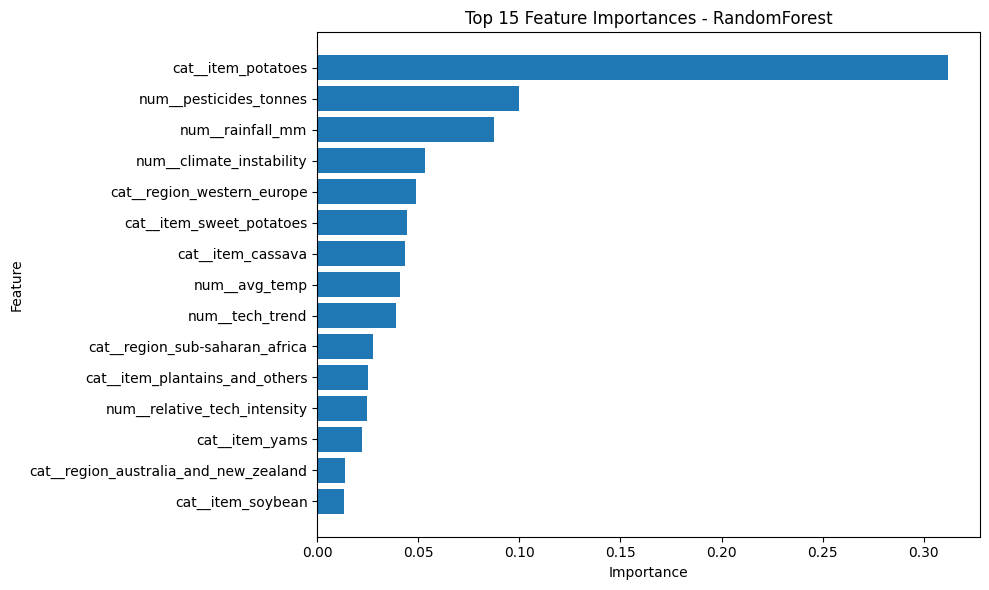


Importance par groupe :
                  group  importance
0                  item    0.489880
1  numeric_climate_tech    0.345472
2                region    0.164648


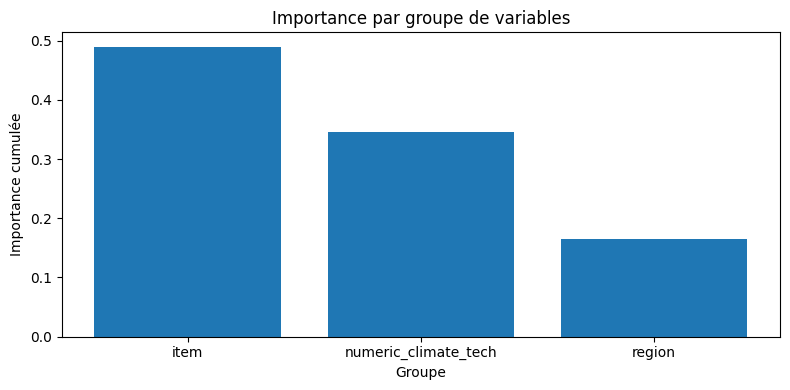

In [15]:
best_pipeline = result["best_pipeline"]
best_params = result["best_params"]
test_metrics = result["test_metrics"]

print("Best params :", best_params)
print("Test metrics :", test_metrics)

# Extraire le modèle et le préprocesseur du pipeline
rf_model = best_pipeline.named_steps["model"]
preprocessor = best_pipeline.named_steps["preprocessor"]

# Récupérer les noms de variables après transformation
feature_names = preprocessor.get_feature_names_out()

# Récupérer les importances
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("\nTop 15 features :")
print(feature_importance_df.head(15))

# Sauvegarder les importances si besoin

feature_importance_df.to_csv("../data/processed/feature_importance_random_forest.csv", index=False)

# Visualisation top 15

top_n = 15
top_features = feature_importance_df.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 15 Feature Importances - RandomForest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Regrouper les variables par famille métier

def feature_group(feature_name: str) -> str:

    if "avg_temp" in feature_name or "rainfall_mm" in feature_name \
       or "pesticides_tonnes" in feature_name or "tech_trend" in feature_name \
       or "climate_instability" in feature_name or "relative_tech_intensity" in feature_name:
        return "numeric_climate_tech"
    
    if "region_" in feature_name:
        return "region"
    
    if "item_" in feature_name:
        return "item"
    
    return "other"

feature_importance_df["group"] = feature_importance_df["feature"].apply(feature_group)

group_importance_df = (
    feature_importance_df
    .groupby("group", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\nImportance par groupe :")
print(group_importance_df)

# Visualisation par groupe

plt.figure(figsize=(8, 4))
plt.bar(group_importance_df["group"], group_importance_df["importance"])
plt.title("Importance par groupe de variables")
plt.xlabel("Groupe")
plt.ylabel("Importance cumulée")
plt.tight_layout()
plt.show()

# Test scénario

In [ ]:
def build_scenario(
    X_reference,
    region_col,
    avg_temp,
    rainfall_mm,
    pesticides_tonnes,
    tech_trend,
    climate_instability,
    relative_tech_intensity,
):
    row = X_reference.iloc[[0]].copy()

    # reset régions
    region_cols = [c for c in X_reference.columns if c.startswith("region_")]
    for c in region_cols:
        row[c] = 0

    # active la région choisie
    row[region_col] = 1

    # variables numériques
    row["avg_temp"] = avg_temp
    row["rainfall_mm"] = rainfall_mm
    row["pesticides_tonnes"] = pesticides_tonnes
    row["tech_trend"] = tech_trend
    row["climate_instability"] = climate_instability
    row["relative_tech_intensity"] = relative_tech_intensity

    return row

In [24]:
def get_crop_columns(X):
    return [col for col in X.columns if col.startswith("item_")]

def recommend_crops(input_row, model, crop_columns):
    results = []

    for crop_col in crop_columns:
        row = input_row.copy()

        for c in crop_columns:
            row[c] = 0

        row[crop_col] = 1

        pred = model.predict(row)[0]

        results.append({
            "crop": crop_col.replace("item_", ""),
            "predicted_yield": pred
        })

    return (
        pd.DataFrame(results)
        .sort_values("predicted_yield", ascending=False)
        .reset_index(drop=True)
    )

In [ ]:
# best_pipeline = mlflow.sklearn.load_model("models:/Yield_Forecaster_GridSearch/latest")

df = pd.read_csv("../data/processed/yield_df_final_conso_encoded.csv", index_col=0)
X_train, X_test, y_train, y_test, categorical_cols, numeric_cols = separation_X_y(df)

crop_cols = get_crop_columns(X_test)

scenarios = {
    "chaud_sec_faible_tech": build_scenario(
        X_reference=X_test,
        region_col="region_sub-saharan_africa",
        avg_temp=28,
        rainfall_mm=400,
        pesticides_tonnes=20,
        tech_trend=0.3,
        climate_instability=0.8,
        relative_tech_intensity=0.3,
    ),
    "tempere_humide_tech_moyenne": build_scenario(
        X_reference=X_test,
        region_col="region_western_europe",
        avg_temp=16,
        rainfall_mm=900,
        pesticides_tonnes=80,
        tech_trend=0.6,
        climate_instability=0.3,
        relative_tech_intensity=0.7,
    ),
    "chaud_humide_tech_forte": build_scenario(
        X_reference=X_test,
        region_col="region_south-eastern_asia",
        avg_temp=26,
        rainfall_mm=1400,
        pesticides_tonnes=100,
        tech_trend=0.8,
        climate_instability=0.4,
        relative_tech_intensity=0.9,
    ),
    "scenario_desert": build_scenario(
    X_reference=X_test,
    region_col="region_northern_africa",
    avg_temp=32,
    rainfall_mm=150,
    pesticides_tonnes=10,
    tech_trend=0.2,
    climate_instability=0.9,
    relative_tech_intensity=0.2,
),
"scenario_tropical" : build_scenario(
    X_reference=X_test,
    region_col="region_south-eastern_asia",
    avg_temp=27,
    rainfall_mm=1800,
    pesticides_tonnes=70,
    tech_trend=0.6,
    climate_instability=0.5,
    relative_tech_intensity=0.7,
)
}

for scenario_name, scenario_row in scenarios.items():
    recs = recommend_crops(scenario_row, best_pipeline, crop_cols)
    print(f"\n=== {scenario_name} ===")
    print(recs.head(5))

2026-04-01 16:03:21,380 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'tech_trend', 'climate_instability', 'relative_tech_intensity']
2026-04-01 16:03:21,380 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams']



=== chaud_sec_faible_tech ===
                   crop  predicted_yield
0                  yams    100369.479792
1              potatoes     90333.308750
2               cassava     67591.462500
3  plantains_and_others     63823.700000
4        sweet_potatoes     52568.989583

=== tempere_humide_tech_moyenne ===
                   crop  predicted_yield
0              potatoes    278634.893750
1  plantains_and_others     94305.266548
2               cassava     83602.403066
3                 maize     78695.455000
4        sweet_potatoes     75305.878192

=== chaud_humide_tech_forte ===
                   crop  predicted_yield
0              potatoes    112691.623614
1                  yams    102221.770112
2               cassava    101250.770327
3  plantains_and_others     91923.776667
4        sweet_potatoes     70058.248554

=== scenario_desert ===
                   crop  predicted_yield
0              potatoes    133370.650179
1               cassava    131566.987500
2        swee